In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaincc, gamma
import pandas as pd
from astropy.io import fits

In [15]:
def chi2(x):
    return np.sum(x**2)

def pval(chi2, dof):
    y= gammaincc(dof/2, chi2/2) #sf
    return y

## chi2 tests

In [20]:
f="data/chi2.csv"
a=pd.read_csv(f)
a.keys()

Index(['Unnamed: 0', 'A', 'B', 'C'], dtype='object')

In [22]:
A=a["A"]
B=a["B"]
C=a["C"]

D=[A, B, C]
for i in range(len(D)):
    CHI2=chi2(D[i])
    print("\n dof:", len(D[i]), "chi2:", CHI2)
    print("reduced chi2:", CHI2/len(D[i]))

    p=pval(CHI2, len(D[i]))
    print('p, 1-p value:', p, 1-p)


 dof: 10 chi2: 8.88882580114591
reduced chi2: 0.888882580114591
p, 1-p value: 0.5426859966002578 0.45731400339974215

 dof: 10 chi2: 65.49113744573323
reduced chi2: 6.549113744573323
p, 1-p value: 3.264458289526491e-10 0.9999999996735541

 dof: 10 chi2: 16.987856095612177
reduced chi2: 1.6987856095612177
p, 1-p value: 0.07463312572242896 0.925366874277571


## ks test

In [23]:
from scipy.special import erf

In [24]:
def read_this(f1):
    '''Reads the given fits file f1, and returns 6 arrays'''
    with fits.open(f1) as hdul:
        hdul.info()
        data = hdul[1].data
        A = data['A'][0]
        B = data['B'][0]
        C = data['C'][0]
        D = data['D'][0]
        E = data['E'][0]
        F = data['F'][0]

    O=[A, B, C, D, E, F]
    return O
def ecdf(x):
    l=len(x)
    y=np.sort(x)
    cdf=np.arange(1, l+1,1)/l
    return y, cdf
def Qks(lam, jmax=1000):
    y=np.zeros(jmax)
    for i in range(len(y)):
        y[i]=(-1)**(i)*np.exp(-2*(i+1)**2*lam**2)
    return 2*np.sum(y)
def pks(D, N, jmax=1000):
    L=(np.sqrt(N)+0.12+0.11/np.sqrt(N))*D
    y=Qks(L, jmax=jmax)
    return y

def ncdf(x):
    return (1 + erf(x / np.sqrt(2)))/2


In [25]:
f="data/ks.fits"
O=read_this(f)

Filename: data/ks.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     20   1R x 6C   [PD(10), PD(30), PD(100), PD(10), PD(30), PD(100)]   



 n: 10
D 0.20520465373496755
K 0.06489140922686756
p, 1-p value: 0.7431155381280397 0.25688446187196035

 n: 30
D 0.11076181597453011
K 0.020222248373162065
p, 1-p value: 0.8336189613368599 0.16638103866314014

 n: 100
D 0.07958193393205293
K 0.007958193393205294
p, 1-p value: 0.5340166672477921 0.46598333275220793

 n: 10
D 0.3793660235789754
K 0.11996607013907046
p, 1-p value: 0.08424950985283758 0.9157504901471625

 n: 30
D 0.2922565850708163
K 0.053358508074237886
p, 1-p value: 0.009120953447133736 0.9908790465528663

 n: 100
D 0.2771499120188119
K 0.02771499120188119
p, 1-p value: 2.839694496581776e-07 0.9999997160305504


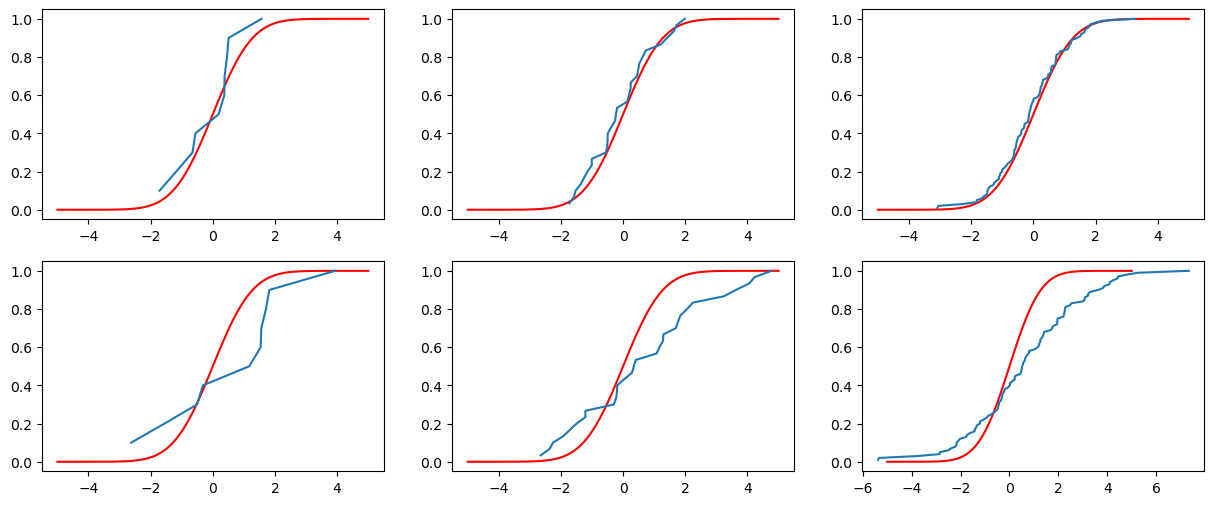

In [26]:
fig, ax=plt.subplots(2,3, figsize=(15,6))
ax=ax.flatten()
x=np.linspace(-5,5,100)
DIFF=[]
for i in range(len(O)):
    ax[i].plot(x, ncdf(x), "r")
    H=ecdf(O[i])
    ax[i].plot(H[0], H[1])
    exp=ncdf(H[0])
    DIFF.append(np.abs(exp-H[1]))
    D=np.max(np.abs(exp-H[1]))
    print("\n n:", len(H[0]))
    print("D", D)
    print("K", D/np.sqrt(len(H[0])))
    print("p, 1-p value:", pks(D, len(H[0])), 1-pks(D, len(H[0])))